# Notebook para o Questionário 2


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

In [12]:
# trecho de código apresentado pelo professor para buscar os dados
import pandas as pd
url = "https://gist.github.com/aishwarya8615/89d9f36fc014dea62487f7347864d16a"
# Read the table from the URL into a dataframe
df = pd.read_html(url)[0]

# limpeza breve das colunas
df.columns = df.columns.str.strip().str.replace(' ', '_')

### Porcentagem dos países desenvolvidos entre 2010 e 2015

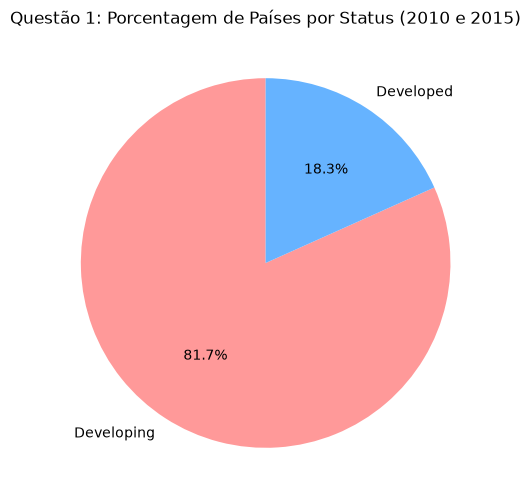

In [13]:
# limitação do tempo para 2010 ~ 2015
df_q1 = df[df['Year'].isin([2010, 2015])] 
status_cont = df_q1['Status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_cont, labels=status_cont.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Questão 1: Porcentagem de Países por Status (2010 e 2015)')
plt.show()

### Histograma para "Life_expectancy"

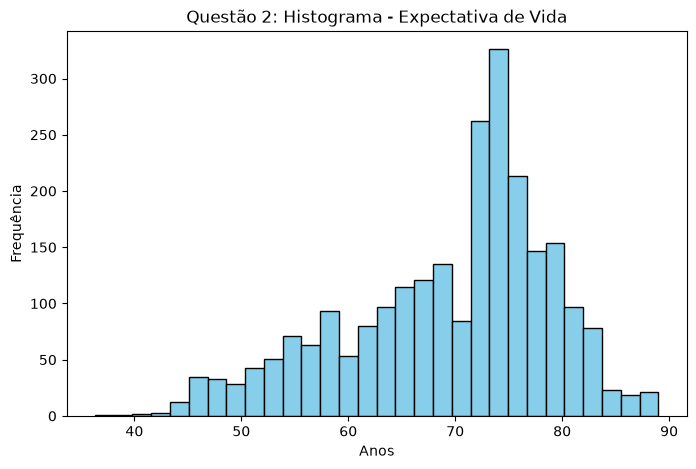

Questão 2 -> Média de Life_expectancy: 69.46
Questão 2 -> Variância de Life_expectancy: 92.92



In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['Life_expectancy'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Questão 2: Histograma - Expectativa de Vida')
plt.xlabel('Anos')
plt.ylabel('Frequência')
plt.show()

media_le = df['Life_expectancy'].mean()
var_le = df['Life_expectancy'].var()
print(f"Questão 2 -> Média de Life_expectancy: {media_le:.2f}")
print(f"Questão 2 -> Variância de Life_expectancy: {var_le:.2f}\n")

### Série temporal de "Life_expectancy" para países específicos

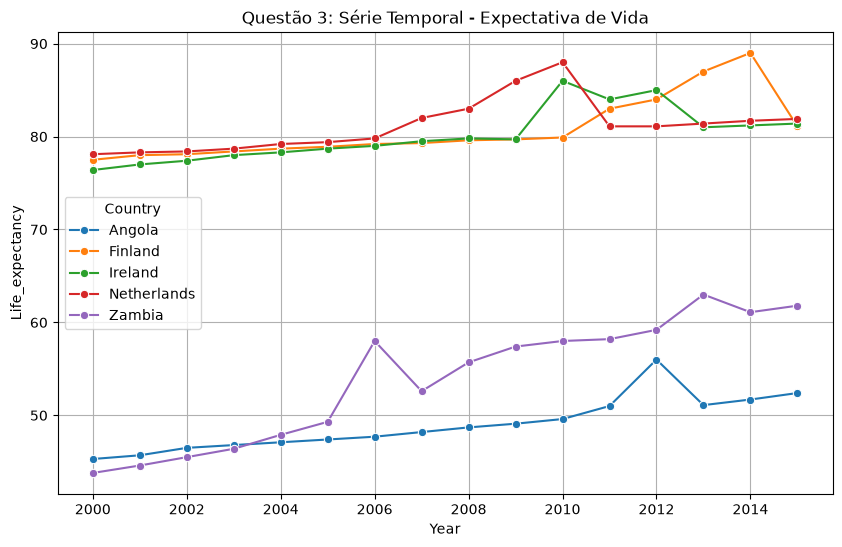

Questão 3 -> Em 2014, País com Maior expectativa: Finland
Questão 3 -> Em 2014, País com Menor expectativa: Angola



In [15]:
paises = ['Ireland', 'Finland', 'Netherlands', 'Zambia', 'Angola']
df_paises = df[df['Country'].isin(paises)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_paises, x='Year', y='Life_expectancy', hue='Country', marker='o')
plt.title('Questão 3: Série Temporal - Expectativa de Vida')
plt.grid(True)
plt.show()

# responde a pergunta dos países com maior e menor expectativa de vida em 2014
df_2014 = df_paises[df_paises['Year'] == 2014]
maior_2014 = df_2014.loc[df_2014['Life_expectancy'].idxmax()]['Country']
menor_2014 = df_2014.loc[df_2014['Life_expectancy'].idxmin()]['Country']
print(f"Questão 3 -> Em 2014, País com Maior expectativa: {maior_2014}")
print(f"Questão 3 -> Em 2014, País com Menor expectativa: {menor_2014}\n")

### Boxplot para "schooling" para países específicos

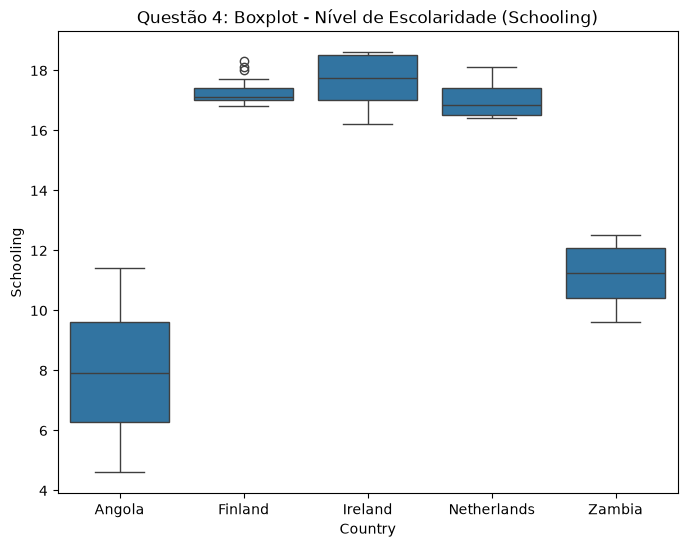

Questão 4 -> Em termos de mediana, o país com maior nível de escolaridade é: Ireland



In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_paises, x='Country', y='Schooling')
plt.title('Questão 4: Boxplot - Nível de Escolaridade (Schooling)')
plt.show()

medianas = df_paises.groupby('Country')['Schooling'].median().sort_values(ascending=False)
maior_mediana = medianas.index[0]
print(f"Questão 4 -> Em termos de mediana, o país com maior nível de escolaridade é: {maior_mediana}\n")

### Matriz de correlação com o segundo dataset

In [17]:
# trecho de código do professor para pegar as informações do segundo dataset
from io import StringIO
url = "https://www.worldometers.info/world-population/population-by-country/"
# Send a GET request to the URL
response = requests.get(url)
# Parse the HTML content with BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')
# Find the table containing the population data (find the first table)
table = soup.find('table')
# Convert the table to a Pandas DataFrame
df = pd.read_html(StringIO(str(table)))[0]
# Print the DataFrame
df.head(10)

,#,Country (or dependency),Population 2026,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1476625576,0.87%,12760051,497,2973190,"−440,456",1.93,29.2,37.6%,17.8%
1,2,China,1412914089,−0.22%,"−3,182,005",150,9388211,"−232,107",1.03,40.6,68.7%,17%
2,3,United States,349035494,0.51%,1759687,38,9147420,1177848,1.63,38.7,83.1%,4.2%
3,4,Indonesia,287886782,0.76%,2165546,159,1811570,"−39,472",2.08,30.7,60.3%,3.5%
4,5,Pakistan,259299791,1.6%,4080237,336,770880,"−1,144,738",3.44,20.8,34.7%,3.1%
5,6,Nigeria,242431832,2.06%,4904050,266,910770,"−2,810",4.21,18.3,55.8%,2.9%
6,7,Brazil,213562666,0.35%,750261,26,8358140,"−205,642",1.59,35.3,91.7%,2.6%
7,8,Bangladesh,177818044,1.21%,2131145,1366,130170,"−371,398",2.09,26.3,43.2%,2.1%
8,9,Russia,143394458,−0.42%,"−602,935",9,16376870,324924,1.47,40.7,75.4%,1.7%
9,10,Ethiopia,138902185,2.53%,3430134,139,1000000,27298,3.72,19.3,22.9%,1.7%


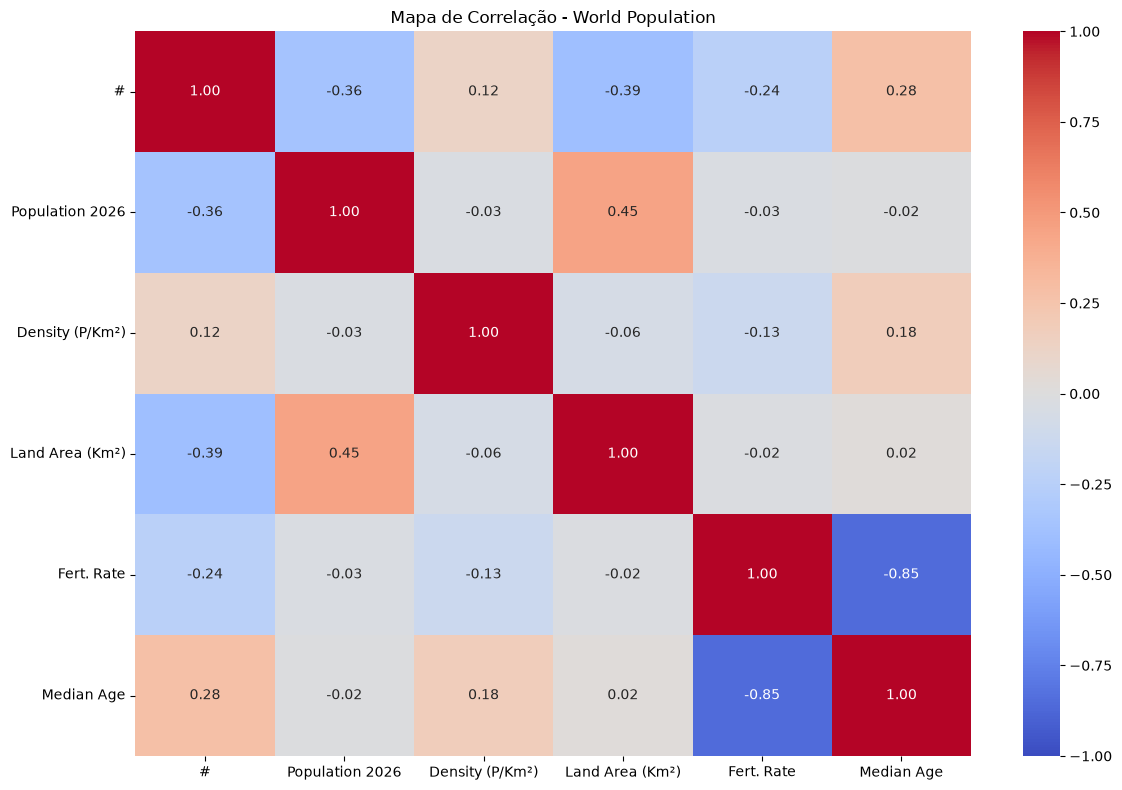

As variáveis menos correlacionadas são: 'Population 2026' e 'Median Age'.
Valor da correlação: -0.01534


In [18]:
# remove '%', ',' e força a conversão para valores numéricos, substituindo texto inválido por NaN
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Country (or dependency)':
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# cálculo da matriz de correlação
matriz_corr = df.corr(numeric_only=True)

# plotagem do mapa de correlação (heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Correlação - World Population')
plt.tight_layout()
plt.show()

# identificação das variáveis menos correlacionadas
matriz_corr_abs = matriz_corr.abs()

# substitui a diagonal principal (correlação 1.0) por NaN de forma segura
for i in range(len(matriz_corr_abs.columns)):
    matriz_corr_abs.iloc[i, i] = np.nan

menor_corr = matriz_corr_abs.unstack().idxmin()
valor_menor = matriz_corr.loc[menor_corr[0], menor_corr[1]]

print(f"As variáveis menos correlacionadas são: '{menor_corr[0]}' e '{menor_corr[1]}'.")
print(f"Valor da correlação: {valor_menor:.5f}")